# Snake Classifier — Pre-trained Model Comparison

This notebook loads the **already-trained** LinearSVC, Logistic Regression, and LightGBM models and evaluates them on a bundled test subset (15 species, ~818 images).

**No training required** — just upload the `colab/` folder and run all cells.

**Outputs:**
- Summary table (Top-1, Top-5, inference time)
- Accuracy bar chart
- Inference speed comparison
- Confusion matrices (side by side)
- Per-class accuracy heatmap
- Classification reports
- ROC curves (one-vs-rest)
- Sample prediction gallery

## 0. Setup

In [ ]:
!pip install -q lightgbm scikit-image tqdm

In [ ]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm.notebook import tqdm

from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, top_k_accuracy_score,
    classification_report, confusion_matrix, roc_curve, auc
)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. Mount Google Drive & Configuration

Run the cell below to mount your Drive. The `colab/` folder contents (dataset + artifacts) should be inside your Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Set this to wherever you uploaded the colab/ folder in Drive ───────────
DRIVE_BASE = '/content/drive/MyDrive/colab'

DATASET_PATH = f'{DRIVE_BASE}/dataset'

MODEL_DIRS = {
    'LinearSVC':          f'{DRIVE_BASE}/artifacts_linearsvc',
    'LogisticRegression':  f'{DRIVE_BASE}/artifacts_logreg',
    'LightGBM':           f'{DRIVE_BASE}/artifacts_lgbm',
}

# Feature config (must match what was used during training)
IMG_SIZE            = (256, 256)
HOG_ORIENTATIONS    = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
LBP_POINTS          = 24
LBP_RADIUS          = 3
HSV_BINS            = (8, 8, 8)

print('Model artifact folders:')
for name, path in MODEL_DIRS.items():
    exists = os.path.exists(path)
    print(f'  {name:25s} → {path}  {"OK" if exists else "MISSING!"}')

Mounted at /content/drive
Model artifact folders:
  LinearSVC                 → /content/drive/MyDrive/colab/artifacts_linearsvc  OK
  LogisticRegression        → /content/drive/MyDrive/colab/artifacts_logreg  OK
  LightGBM                  → /content/drive/MyDrive/colab/artifacts_lgbm  OK


## 2. Load Pre-trained Models

In [ ]:
loaded_models = {}

for name, adir in MODEL_DIRS.items():
    print(f'Loading {name}...')
    loaded_models[name] = {
        'scaler':      joblib.load(os.path.join(adir, 'scaler.pkl')),
        'pca':         joblib.load(os.path.join(adir, 'pca.pkl')),
        'model':       joblib.load(os.path.join(adir, 'model.pkl')),
        'label_names': joblib.load(os.path.join(adir, 'label_names.pkl')),
    }
    lnames = loaded_models[name]['label_names']
    print(f'  Classes in model: {len(lnames)}')

print(f'\nAll {len(loaded_models)} models loaded.')

Loading LinearSVC...
  Classes in model: 250
Loading LogisticRegression...
  Classes in model: 250
Loading LightGBM...
  Classes in model: 250

All 3 models loaded.


## 3. Feature Extraction (HOG + LBP + HSV)

In [ ]:
def preprocess_image(image_path):
    """Read and resize. No augmentation during evaluation."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    return cv2.resize(img, IMG_SIZE)


def extract_features(img_bgr):
    """HOG + LBP + HSV colour histogram → single 1-D vector."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # HOG
    hog_feat = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=False
    ).astype(np.float32)

    # LBP
    lbp = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method='uniform')
    n_bins = int(lbp.max() + 1)
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    lbp_hist = lbp_hist.astype(np.float32)

    # HSV colour
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hsv_hist = cv2.calcHist([hsv], [0, 1, 2], None, HSV_BINS, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hsv_hist, hsv_hist)
    hsv_hist = hsv_hist.flatten().astype(np.float32)

    return np.hstack([hog_feat, lbp_hist, hsv_hist])

## 4. Extract Features from Test Dataset

In [ ]:
# Build a mapping from species name → model label index
# (the models were trained on all 250 classes, we test on 15)
ref_label_names = loaded_models[list(loaded_models.keys())[0]]['label_names']
species_to_idx = {name: idx for idx, name in enumerate(ref_label_names)}

species_folders = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print(f'Test species ({len(species_folders)}):')
test_species_names = []
for s in species_folders:
    idx = species_to_idx.get(s, '???')
    print(f'  {s:40s} → model class index {idx}')
    test_species_names.append(s)

# Extract features
features = []
true_labels = []    # model-level class indices
image_paths = []

for species in tqdm(species_folders, desc='Extracting features'):
    species_dir = os.path.join(DATASET_PATH, species)
    model_idx = species_to_idx.get(species)
    if model_idx is None:
        print(f'  WARNING: {species} not found in model label_names, skipping.')
        continue

    imgs = [
        f for f in os.listdir(species_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    for img_file in imgs:
        img_path = os.path.join(species_dir, img_file)
        img = preprocess_image(img_path)
        if img is None:
            continue
        feat = extract_features(img)
        features.append(feat)
        true_labels.append(model_idx)
        image_paths.append(img_path)

X_raw = np.array(features, dtype=np.float32)
y_true = np.array(true_labels)

print(f'\nFeature matrix: {X_raw.shape}  |  Test images: {len(y_true)}')

Test species (15):
  Achalinus_niger                          → model class index 0
  Atractus_carrioni                        → model class index 16
  Bothrocophias_microphthalmus             → model class index 32
  Coniophanes_lateritius                   → model class index 48
  Crotalus_tzabcan                         → model class index 64
  Eirenis_levantinus                       → model class index 80
  Gloydius_intermedius                     → model class index 96
  Laticauda_laticaudata                    → model class index 112
  Mastigodryas_pulchriceps                 → model class index 128
  Naja_haje                                → model class index 144
  Oxyrhabdium_modestum                     → model class index 160
  Philothamnus_natalensis                  → model class index 176
  Pseudalsophis_elegans                    → model class index 192
  Spilotes_sulphureus                      → model class index 208
  Trimeresurus_albolabris                  → model 

Extracting features:   0%|          | 0/15 [00:00<?, ?it/s]


Feature matrix: (818, 35134)  |  Test images: 818


## 5. Run Inference with All Models

In [ ]:
results = {}

for name, m in loaded_models.items():
    print(f'\n{"="*50}')
    print(f'Evaluating {name}...')

    # Apply the same preprocessing pipeline: scaler → PCA
    X = m['scaler'].transform(X_raw)
    X = m['pca'].transform(X)

    # Time the inference
    t0 = time.time()
    y_pred = m['model'].predict(X)
    infer_time = time.time() - t0

    top1 = accuracy_score(y_true, y_pred)

    # Get scores for Top-5 and ROC
    if hasattr(m['model'], 'decision_function'):
        scores = m['model'].decision_function(X)
    elif hasattr(m['model'], 'predict_proba'):
        scores = m['model'].predict_proba(X)
    else:
        scores = None

    top5 = top_k_accuracy_score(y_true, scores, k=5, labels=np.arange(len(ref_label_names))) if scores is not None else float('nan')

    print(f'  Top-1: {top1*100:.2f}%  |  Top-5: {top5*100:.2f}%')
    print(f'  Inference time: {infer_time:.4f}s ({len(y_true)/infer_time:.0f} imgs/sec)')

    results[name] = {
        'y_pred': y_pred, 'scores': scores,
        'top1': top1, 'top5': top5,
        'infer_time': infer_time,
    }

print(f'\n{"="*50}\nAll models evaluated.')


Evaluating LinearSVC...
  Top-1: 5.99%  |  Top-5: 13.94%
  Inference time: 0.0126s (64710 imgs/sec)

Evaluating LogisticRegression...
  Top-1: 8.68%  |  Top-5: 15.04%
  Inference time: 0.0049s (167953 imgs/sec)

Evaluating LightGBM...
  Top-1: 10.51%  |  Top-5: 15.89%
  Inference time: 12.0545s (68 imgs/sec)

All models evaluated.


## 6. Results Summary Table

In [ ]:
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Top-1 Accuracy (%)': [r['top1']*100 for r in results.values()],
    'Top-5 Accuracy (%)': [r['top5']*100 for r in results.values()],
    'Inference Time (s)': [r['infer_time'] for r in results.values()],
    'Throughput (imgs/s)': [len(y_true)/r['infer_time'] for r in results.values()],
}).set_index('Model')

summary.style.format('{:.2f}').background_gradient(
    cmap='Greens', subset=['Top-1 Accuracy (%)', 'Top-5 Accuracy (%)'])

,Top-1 Accuracy (%),Top-5 Accuracy (%),Inference Time (s),Throughput (imgs/s)
Model,,,,
LinearSVC,5.99,13.94,0.01,64710.31
LogisticRegression,8.68,15.04,0.00,167952.84
LightGBM,10.51,15.89,12.05,67.86


## 7. Accuracy Bar Chart

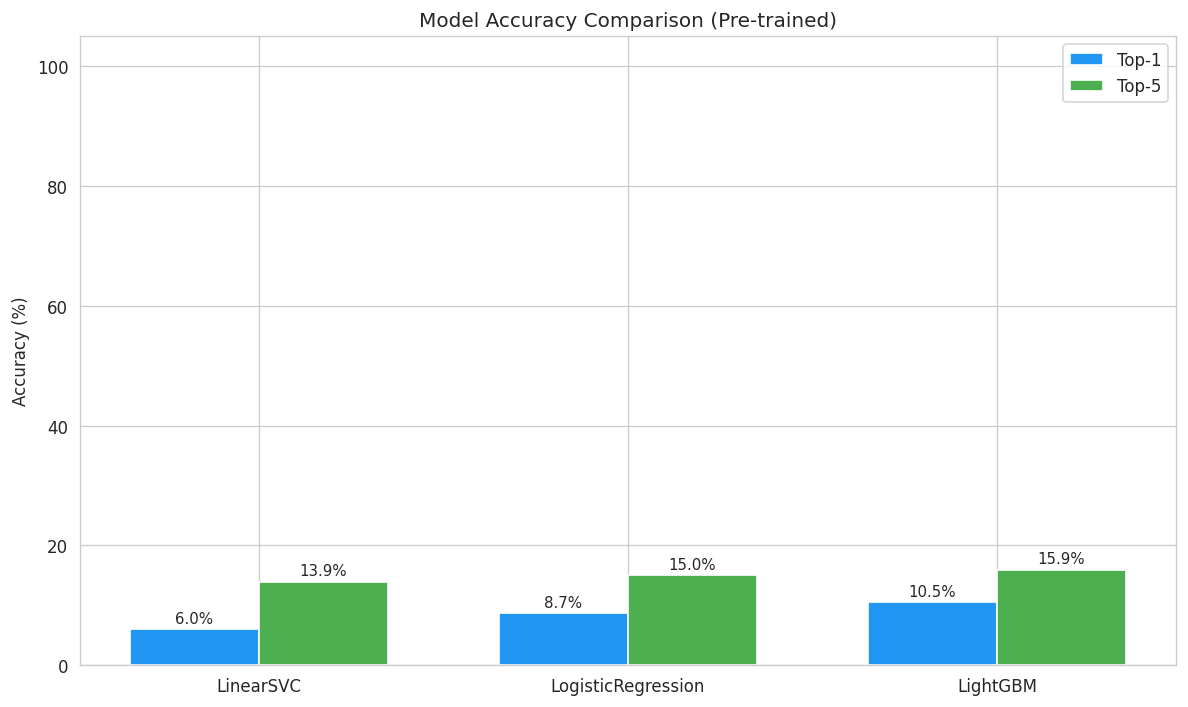

In [ ]:
model_names = list(results.keys())
top1_vals = [results[n]['top1']*100 for n in model_names]
top5_vals = [results[n]['top5']*100 for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, top1_vals, width, label='Top-1', color='#2196F3')
bars2 = ax.bar(x + width/2, top5_vals, width, label='Top-5', color='#4CAF50')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison (Pre-trained)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 105)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', bbox_inches='tight')
plt.show()

## 8. Inference Speed Comparison

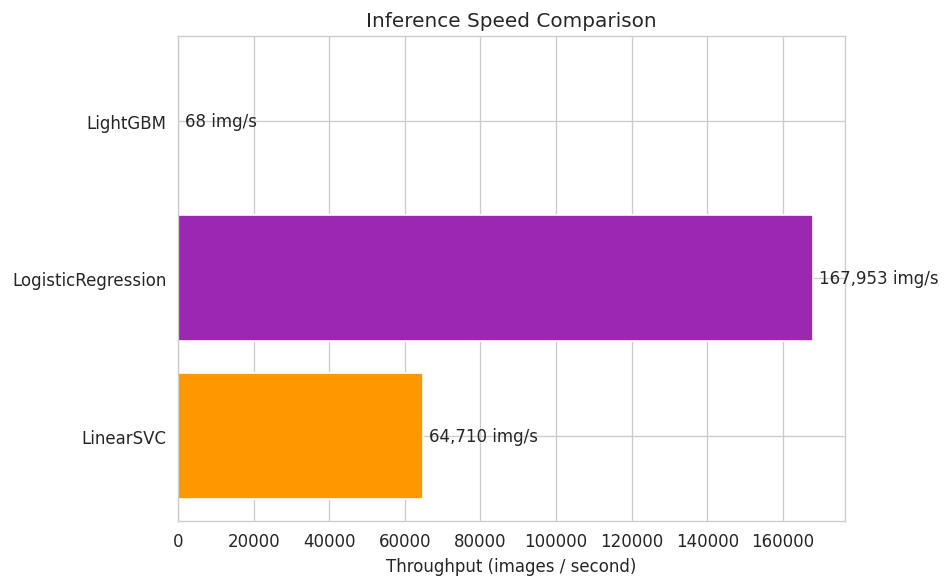

In [ ]:
throughputs = [len(y_true)/results[n]['infer_time'] for n in model_names]
colors = ['#FF9800', '#9C27B0', '#00BCD4']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(model_names, throughputs, color=colors[:len(model_names)])
ax.set_xlabel('Throughput (images / second)')
ax.set_title('Inference Speed Comparison')

for bar, t in zip(bars, throughputs):
    ax.text(bar.get_width() + max(throughputs)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{t:,.0f} img/s', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('inference_speed.png', bbox_inches='tight')
plt.show()

## 9. Confusion Matrices

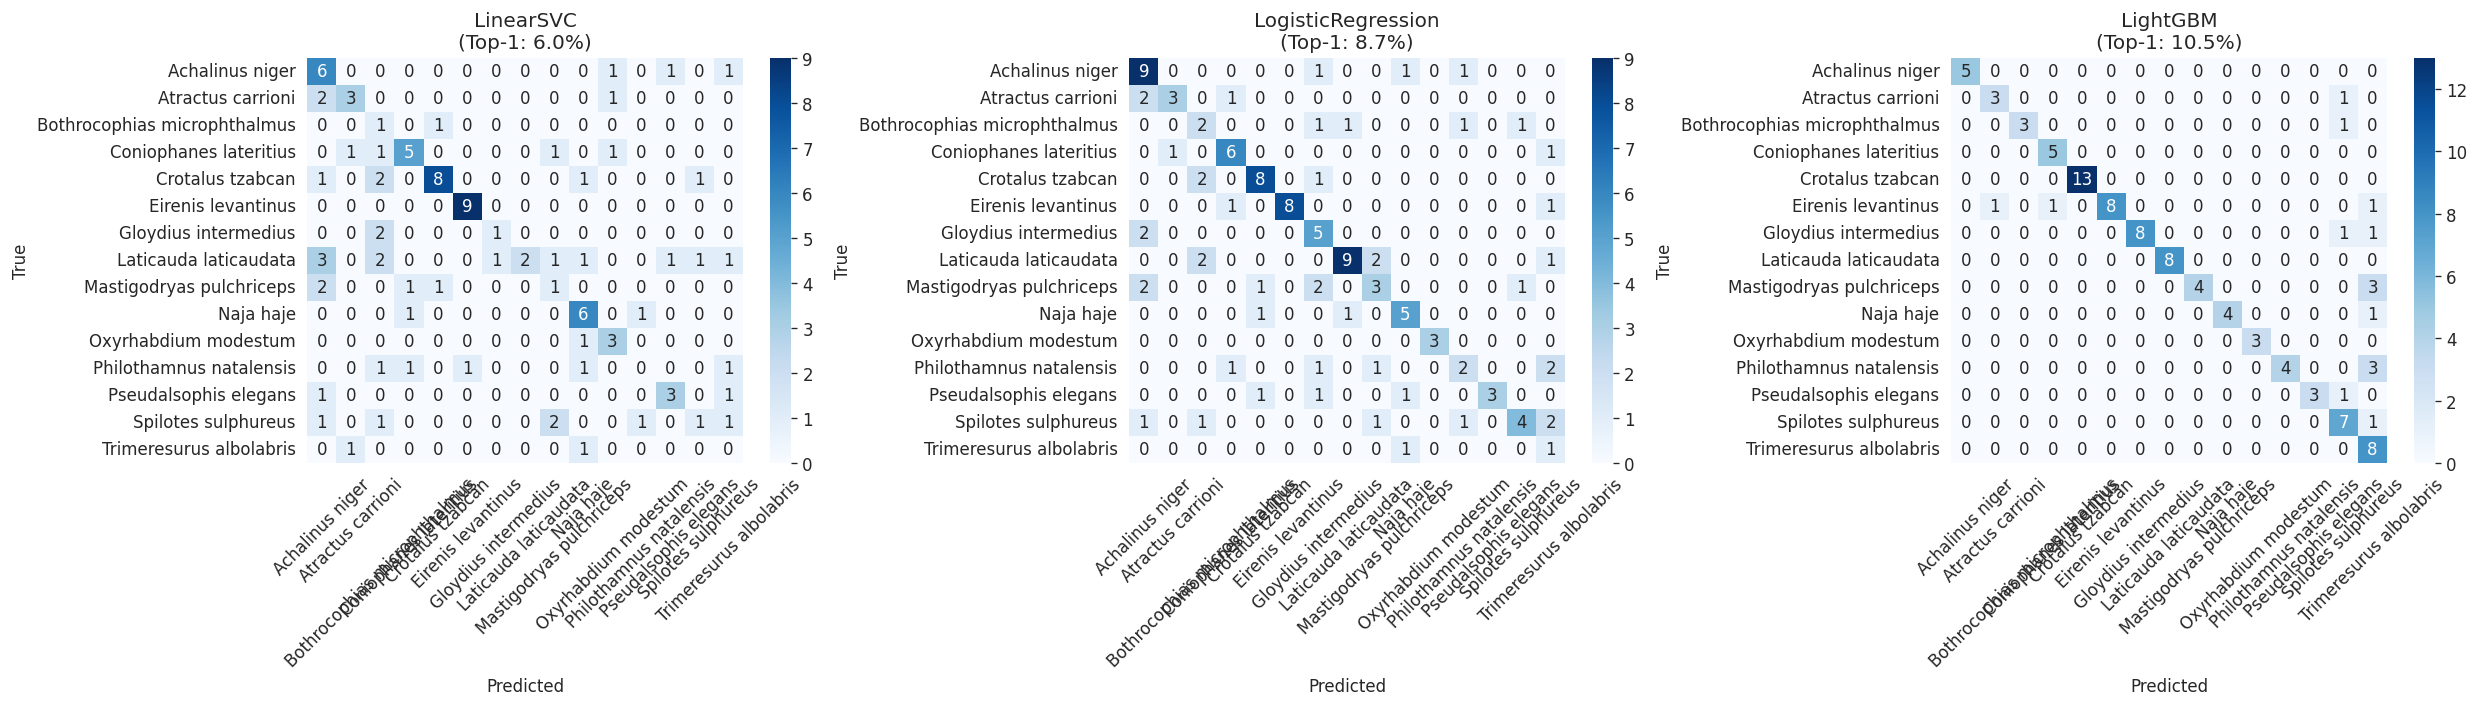

In [ ]:
# Get the subset of class indices that appear in our test set
test_class_indices = sorted(set(y_true))
short_labels = [ref_label_names[i].replace('_', ' ') for i in test_class_indices]

fig, axes = plt.subplots(1, len(results), figsize=(7*len(results), 6))
if len(results) == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_true, r['y_pred'], labels=test_class_indices)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=short_labels, yticklabels=short_labels)
    ax.set_title(f'{name}\n(Top-1: {r["top1"]*100:.1f}%)')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

## 10. Per-Class Accuracy Heatmap

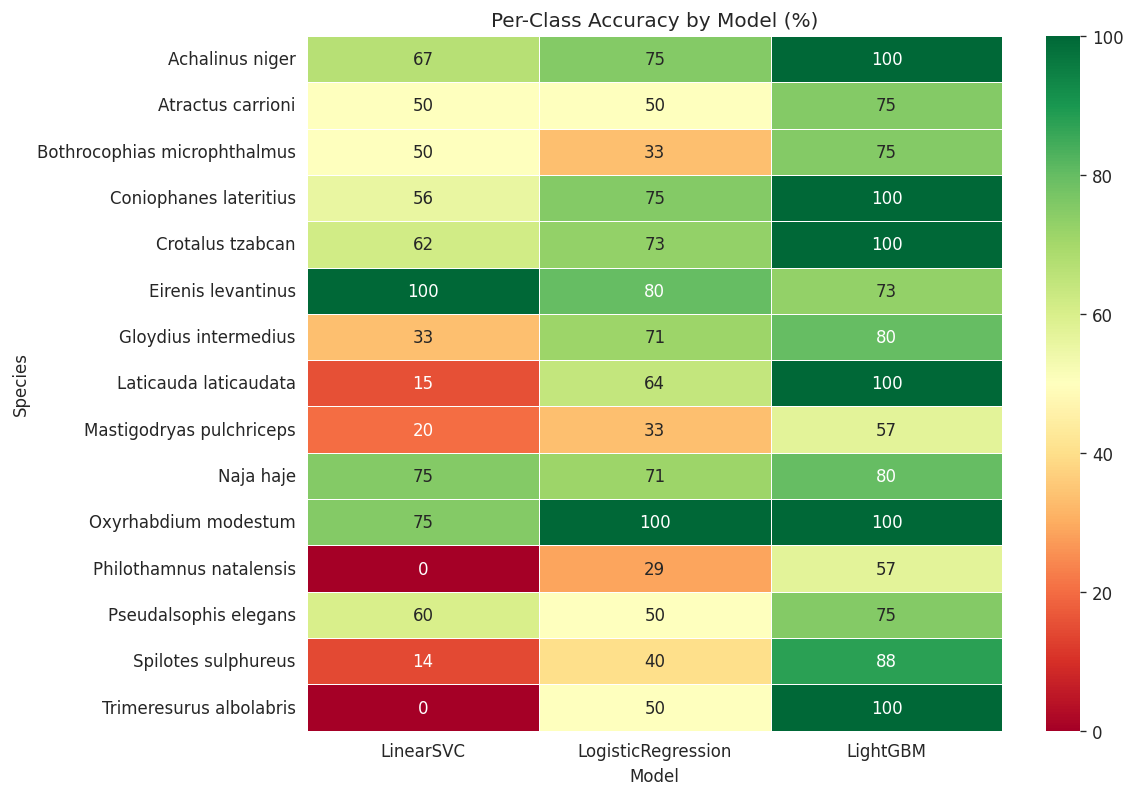

In [ ]:
per_class_acc = {}
for name, r in results.items():
    cm = confusion_matrix(y_true, r['y_pred'], labels=test_class_indices)
    row_sums = cm.sum(axis=1)
    acc = np.where(row_sums > 0, cm.diagonal() / row_sums, 0) * 100
    per_class_acc[name] = acc

df_pca = pd.DataFrame(per_class_acc, index=short_labels)

fig, ax = plt.subplots(figsize=(10, max(4, len(test_class_indices)*0.45)))
sns.heatmap(df_pca, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax,
            vmin=0, vmax=100, linewidths=0.5)
ax.set_title('Per-Class Accuracy by Model (%)')
ax.set_xlabel('Model')
ax.set_ylabel('Species')

plt.tight_layout()
plt.savefig('per_class_accuracy.png', bbox_inches='tight')
plt.show()

## 11. Classification Reports

In [ ]:
for name, r in results.items():
    print(f'\n{"="*60}')
    print(f'Classification Report — {name}')
    print('='*60)
    print(classification_report(
        y_true, r['y_pred'],
        labels=test_class_indices,
        target_names=short_labels,
        zero_division=0
    ))


Classification Report — LinearSVC
                              precision    recall  f1-score   support

             Achalinus niger       0.38      0.10      0.16        60
           Atractus carrioni       0.60      0.06      0.11        50
Bothrocophias microphthalmus       0.10      0.02      0.03        60
      Coniophanes lateritius       0.62      0.10      0.18        48
            Crotalus tzabcan       0.80      0.13      0.23        60
          Eirenis levantinus       0.90      0.18      0.30        50
        Gloydius intermedius       0.50      0.02      0.03        60
       Laticauda laticaudata       1.00      0.03      0.06        60
    Mastigodryas pulchriceps       0.20      0.02      0.03        60
                   Naja haje       0.55      0.12      0.20        50
        Oxyrhabdium modestum       0.50      0.07      0.13        40
     Philothamnus natalensis       0.00      0.00      0.00        60
       Pseudalsophis elegans       0.60      0.07     

## 12. ROC Curves (One-vs-Rest, macro average)

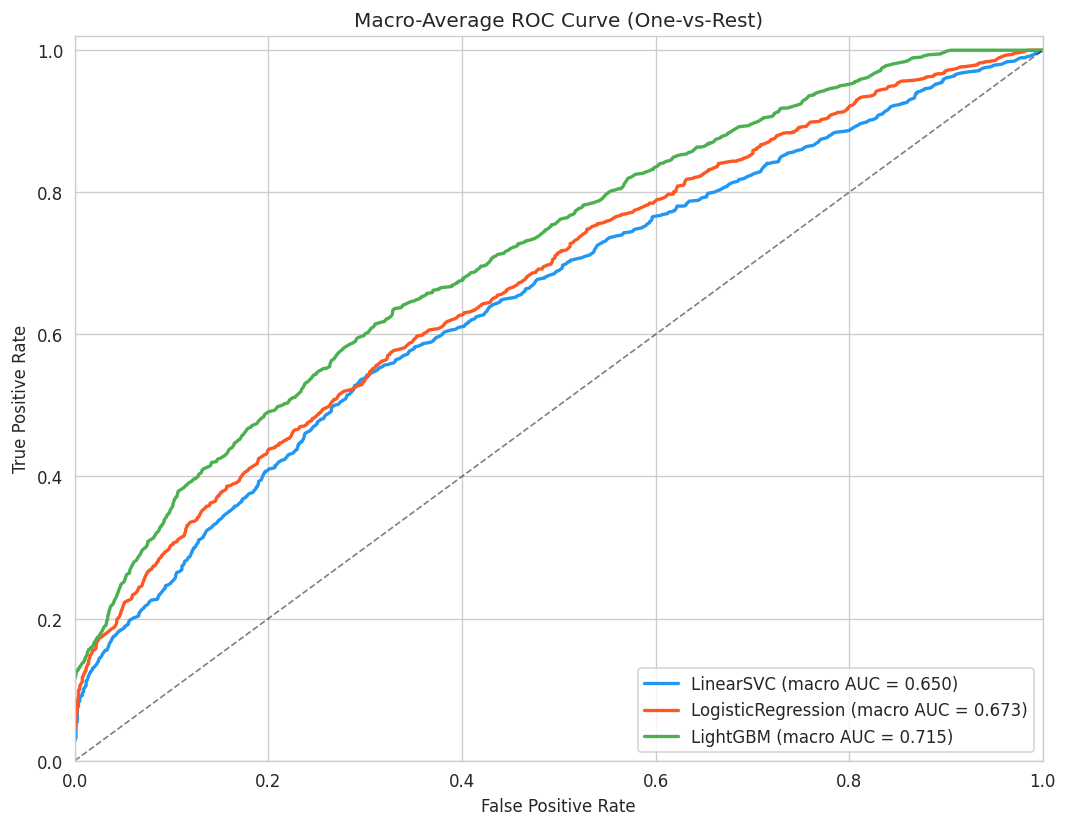

In [ ]:
# Binarize labels for the test subset only
y_true_bin = label_binarize(y_true, classes=test_class_indices)
n_test_classes = len(test_class_indices)

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#2196F3', '#FF5722', '#4CAF50']

def to_proba(scores):
    """Convert decision scores to probabilities via softmax."""
    if np.allclose(scores.sum(axis=1), 1.0, atol=0.1):
        return scores
    exp_s = np.exp(scores - scores.max(axis=1, keepdims=True))
    return exp_s / exp_s.sum(axis=1, keepdims=True)

for idx, (name, r) in enumerate(results.items()):
    if r['scores'] is None:
        continue
    proba = to_proba(r['scores'])
    # Extract only the columns for our test classes
    proba_subset = proba[:, test_class_indices]

    fpr_all, tpr_all = [], []
    for c in range(n_test_classes):
        fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, c], proba_subset[:, c])
        fpr_all.append(fpr_c)
        tpr_all.append(tpr_c)

    all_fpr = np.unique(np.concatenate(fpr_all))
    mean_tpr = np.zeros_like(all_fpr)
    for fpr_c, tpr_c in zip(fpr_all, tpr_all):
        mean_tpr += np.interp(all_fpr, fpr_c, tpr_c)
    mean_tpr /= n_test_classes

    roc_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color=colors_roc[idx % len(colors_roc)],
            lw=2, label=f'{name} (macro AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Macro-Average ROC Curve (One-vs-Rest)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

## 13. Sample Predictions Gallery

In [ ]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

n_samples = min(8, len(y_true))
sample_indices = np.random.choice(len(y_true), n_samples, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, si in enumerate(sample_indices):
    ax = axes[i // 4][i % 4]

    img = cv2.imread(image_paths[si])
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center', transform=ax.transAxes)

    true_species = ref_label_names[y_true[si]]

    pred_lines = []
    for name, r in results.items():
        pred_species = ref_label_names[r['y_pred'][si]]
        if r['scores'] is not None:
            s = r['scores'][si]
            if not np.allclose(s.sum(), 1.0, atol=0.1):
                s = softmax(s)
            conf = s.max() * 100
        else:
            conf = 0
        ok = 'Y' if r['y_pred'][si] == y_true[si] else 'X'
        short_pred = pred_species.replace('_', ' ')
        pred_lines.append(f'{name[:6]}: {short_pred[:20]} {conf:.0f}% [{ok}]')

    ax.set_title(f'True: {true_species.replace("_", " ")}', fontsize=9, fontweight='bold')
    ax.set_xlabel('\n'.join(pred_lines), fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Sample Predictions (Y = correct, X = wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_predictions.png', bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 14. Final Verdict

In [ ]:
best_model = max(results.items(), key=lambda x: x[1]['top1'])
fastest_model = max(results.items(), key=lambda x: len(y_true)/x[1]['infer_time'])

print('='*60)
print('FINAL COMPARISON SUMMARY')
print('='*60)
print(f'\nBest Top-1 Accuracy  : {best_model[0]} ({best_model[1]["top1"]*100:.2f}%)')
print(f'Fastest Inference    : {fastest_model[0]} ({len(y_true)/fastest_model[1]["infer_time"]:,.0f} imgs/sec)')
print()

print(f'{"Model":<22} {"Top-1":>8} {"Top-5":>8} {"Throughput":>14}')
print('-'*55)
for name, r in results.items():
    tput = len(y_true) / r['infer_time']
    print(f'{name:<22} {r["top1"]*100:>7.2f}% {r["top5"]*100:>7.2f}% {tput:>11,.0f} img/s')
print()
print('Saved plots: accuracy_comparison.png, inference_speed.png,')
print('             confusion_matrices.png, per_class_accuracy.png,')
print('             roc_curves.png, sample_predictions.png')

FINAL COMPARISON SUMMARY

Best Top-1 Accuracy  : LightGBM (10.51%)
Fastest Inference    : LogisticRegression (167,953 imgs/sec)

Model                     Top-1    Top-5     Throughput
-------------------------------------------------------
LinearSVC                 5.99%   13.94%      64,710 img/s
LogisticRegression        8.68%   15.04%     167,953 img/s
LightGBM                 10.51%   15.89%          68 img/s

Saved plots: accuracy_comparison.png, inference_speed.png,
             confusion_matrices.png, per_class_accuracy.png,
             roc_curves.png, sample_predictions.png
